# **Demo: Contagem e Avaliação de Moedas em Imagens**

## **Introdução**

O objetivo deste Notebook é demonstrar como podemos utilizar técnicas de análise de imagens e reconhecimentos de padrões para identificar moedas em uma imagem e calcular o seu valor total.

Esse problema será dividido em duas partes:

1 - **Detecção (Onde estão as moedas?)**: Encontrar a localização e o contorno de cada moeda na imagem.

2 - **Classificação (Qual o valor de cada uma?)**: Identificar a qual denominação (ex: 5, 10, 25, 50 centavos ou 1 Real) a moeda pertence, baseando-se em características geométricas (como o tamanho/raio).


Nesse Notebook será utilizado imagens fornecidas para a disciplina, que são fotos de moedas em um fundo branco tiradas de uma mesma altura. as imagens já estão também anotadas com o seu valor total como nome do arquivo.

A seguir o código para realizar download das imagens utilizadas como exemplo nesse notebook.






In [ ]:
# Importando bibliotecas utilizadas nessa demo
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
import cv2

In [ ]:
def download_image(url:str) -> str:
    """
    Downloads an image from a given URL and saves it to the current directory.

    Args:
        url (str): The URL of the image to download.

    Returns:
        str: The filename of the downloaded image.
    """
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

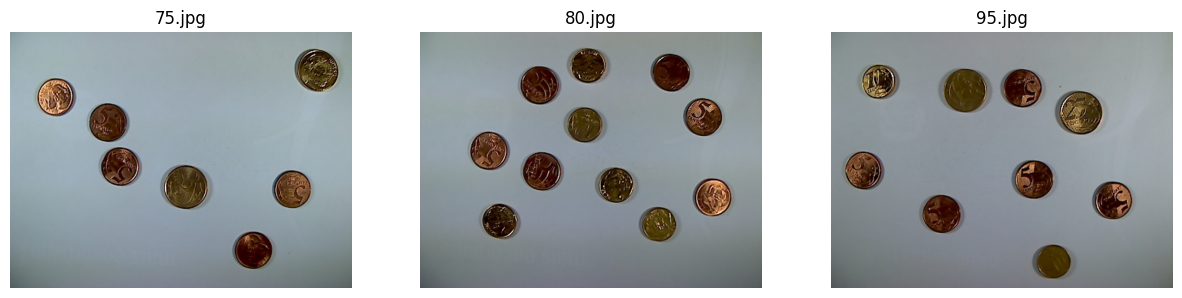

In [ ]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)


fig, axs = plt.subplots(1,3,figsize=(15, 6))

for i, file in enumerate(filenames):
  plt.subplot(1,3,1+i)
  plt.axis('off')
  plt.title(file)
  img = mpimg.imread(file)
  plt.imshow(img)


Para etapa de detecção é utilizado a Limiarização de Otsu e operacões morfológicas da biblioteca **OpenCV**



## Limiarização (Método de Otsu)

A limiarização utilizando o método de Otsu encontra o limite (thresholding) de forma automática, em uma imagem em escala de cinza, tudo acima desse limite é colocado como branco (255) e tudo abaixo desse limite é colocado como preto (0),


a biblioteca openCV possui o método [threshold](https://docs.opencv.org/3.4/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57) que aplica a limiarização, sendo necessário informar o type, como o cv.THRESH_BINARY ou o THRESH_BINARY_INV, a diferença entre esses dois é onde é adicionado o valor máximo, isto é THRESH_BINARY_INV deixa todos os valores acima do threshold branco, as funções a seguir exemplificam o que é feito em cada função

$$\mathtt{THRESHBINARY}(x,y) = \begin{cases} \mathtt{maxval} & \text{if } \mathtt{src}(x,y) > \mathtt{thresh} \\ 0 & \text{otherwise} \end{cases}$$

<br>

$$\mathtt{THRESHBINARYINV}(x,y) = \begin{cases} \ 0 \\ \mathtt{maxval} & \text{if } \mathtt{src}(x,y) > \mathtt{thresh} & \text{otherwise} \end{cases}$$
<br>

Em operações morfológicas, o OpenCV assume que o "objeto de interesse" (neste caso, as moedas) é branco (pixel valor 255) e o fundo é preto (pixel valor 0), logo nesse notebook é utilizado o THRESH_BINARY_INV.

Em vez de ter que "chutar" um valor de corte (threshold) para transformar a imagem em preto e branco (binária) utilizando o THRESH_OTSU isso é feito de forma automática.

ao final da etapa de segmentação A função cv2.threshold retorna dois valores: o valor do threshold calculado e a imagem resultante. mais detalhes podem ser consultados na [documentação ofical do OpenCV](https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html).





## Operações morfológicas

Após a binarização da imagem é comum que exista **ruído na imagem**, como pontos em brancos ou então conexão entre duas ou mais moedas, uma forma de regularizar a imagem é executando operações morfológicas. detalhes sobre esses conceitos são encontrados na documentação oficial : https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html


### Kernels

Pode-se imaginar kernel como uma pequena "janela" ou uma lente de aumento que desliza sobre a sua imagem original, pixel por pixel, do canto superior esquerdo até o canto inferior direito, ele é utilizado nos métodos de Fechamento Mofológico e Abertura Morfológica.


### Fechamento Morfológico

Ele serve para "fechar" pequenos buracos negros dentro dos objetos brancos. Imagine que a sua moeda brilhou com o flash da câmera e, ao binarizar, ficou um "furo" preto no meio da moeda branca. O fechamento preenche esse furo, tornando a moeda um círculo sólido perfeito, sem alterar muito o tamanho original do contorno.


### Abertura Morfológica

Serve para remover ruídos brancos no fundo preto (como sujeirinhas na mesa que foram detectadas como objetos). Além disso, a abertura é excelente para separar objetos que estão levemente encostados uns nos outros. Se duas moedas estiverem se tocando e formando uma "massa de pixels" única, a abertura pode "corroer" essa ponte entre elas e separá-las, o que é vital para não contarmos duas moedas como se fossem uma só.


## Cálculo do valor total

Uma vez que se há a imagem segmentada, o método **cv2.connectedComponentsWithStats** rotula e coleta estatistica sobre os elementos de cada objeto identificado, com esse método é possível localizar os centróides de cada objeto, o número total de objetos a área de cada objeto.


conhecendo o objeto identificado por um rótulo e sua área, é possível atribuir um valor monetário para cada área identificada.

nesse notebook utilizou-se os seguintes critérios de classificação para as moedas:

| Condição no Código |	Intervalo da Área (em pixels) |	Valor Atribuído |	Interpretação |
| -----------|-----|------|-----|
|if area < 3500: |	Menor que 3500 |	10 (centavos)	| Moedas pequenas |
|else:	| Entre 3500 e 4600 (inclusive)|	5 (centavos)	|Moedas de tamanho médio |
elif area > 4600:|	Maior que 4600|	25 (centavos)|	Moedas grandes|

<br>

O código abaixo implementa o contador de moedas a partir de uma imagem.





In [ ]:
class ContadordeMoedas:
    def __init__(self, img):
        """
        Inicializa a classe ContadordeMoedas com a cópia de uma imagem, preservando a imagem original.

        Args:
            img (numpy.ndarray): A imagem de entrada para contagem de moedas.
        """
        self.img = img.copy()

    def colorida_para_cinza(self):
        """
        Converte a imagem colorida armazenada em uma imagem em escala de cinza usando o conceito de luminescência.

        Returns:
            numpy.ndarray: A imagem convertida em escala de cinza.
        """
        return np.uint8(0.3*self.img[:,:,0]+0.59*self.img[:,:,1]+0.11*self.img[:,:,2])

    def segmenta_moedas(self, img_cinza, k_cl, k_op):
        """
        Segmenta as moedas na imagem em escala de cinza usando limiarização de Otsu
        e operações morfológicas de fechamento e abertura.

        Args:
            img_cinza (numpy.ndarray): A imagem em escala de cinza.
            k_cl (int): Tamanho do kernel para a operação de fechamento.
            k_op (int): Tamanho do kernel para a operação de abertura.

        Returns:
            numpy.ndarray: A imagem binária segmentada com as moedas.
        """
        # Usando THRESH_BINARY_INV em vez de 255 - img (mesmo resultado, código mais limpo)
        _, binr = cv2.threshold(img_cinza, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        kernel_cl = np.ones((k_cl, k_cl), np.uint8)
        kernel_op = np.ones((k_op, k_op), np.uint8)

        close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
        open_img = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

        return open_img

    def anota_imagem_e_retorna_valor_total(self, num_labels, stats, centroids):
        """
        Anota a imagem com o valor de cada moeda detectada e calcula o valor total.
        Exibe a imagem anotada com o valor total.

        Args:
            num_labels (int): Número total de componentes conectados (incluindo o fundo).
            stats (numpy.ndarray): Estatísticas de cada componente conectado, incluindo área.
            centroids (numpy.ndarray): Centroides de cada componente conectado.

        Returns:
            int: O valor total das moedas em centavos.
        """
        soma = 0

        # O label 0 é sempre o fundo (background), então iteramos a partir do 1
        for i in range(1, num_labels):
            # Extrai a área (número de pixels) diretamente do 'stats'
            area = stats[i, cv2.CC_STAT_AREA]

            # Extrai as coordenadas X e Y do centroide para posicionar o texto
            x = int(centroids[i][0])
            y = int(centroids[i][1])

            # Sua lógica de classificação de valor por área
            if area < 3500:
                valor = 10
            elif area > 4600:
                valor = 25
            else:
                valor = 5

            soma += valor

            # Anota na imagem da classe (self.img, cópia da imagem original)
            cv2.putText(self.img, str(valor), (x - 10, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Plota o resultado final
        plt.figure(figsize=(8, 6))
        plt.imshow(self.img)
        plt.title(f"Valor Total: {soma} centavos")
        plt.axis('off')
        plt.show()

        return soma

    def contar(self):
        """
        Realiza o processo completo de contagem de moedas:
        1. Converte a imagem para escala de cinza.
        2. Segmenta as moedas usando limiarização e operações morfológicas.
        3. Encontra os componentes conectados e suas estatísticas.
        4. Anota a imagem com os valores das moedas e calcula o total.
        """
        imagem_cinza = self.colorida_para_cinza()
        imagem_segmentada = self.segmenta_moedas(imagem_cinza, 15, 31)

        # Extraindo todos os dados do connectedComponents
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(imagem_segmentada, connectivity=4)

        # Passamos os dados corretos para a função de anotação
        soma = self.anota_imagem_e_retorna_valor_total(num_labels, stats, centroids)

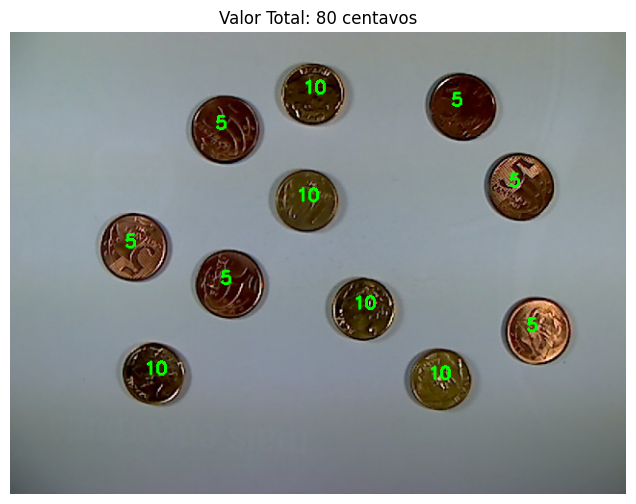

In [ ]:
imagem_80 = filenames[1]
img = mpimg.imread(imagem_80).astype('uint8')
ContadordeMoedas(img).contar()